# **ThermoModel v2: Bands That Account for Diminishing Returns**

The goal is unchanged: a corridor whose upper edge marks cycle tops and whose lower edge marks cycle bottoms. What changes is how the bands are built, because the original model has two structural problems that show up exactly where it hurts - predicting tops.

## What was wrong

The original ThermoModel fits a **cubic polynomial in day index** to log price, then adds **fixed offsets in log space** for the bands.

1. A cubic in raw time extrapolates explosively upward. That is the *opposite* of diminishing returns, and it is why the upper band runs away: run out-of-sample on the 2020-2025 cycle, the original approach projected a top near **$495,000** against an actual **$125,000**.
2. A fixed offset in log space means the band keeps a constant multiplicative width forever. If cycle amplitude is compressing, no fixed offset can track it - too wide late, or too narrow early. In 2017 the same approach put the upper band *below* the actual top (-39%), so price simply broke through it.

## What the data actually says

Measured against a power-law trend (`log10(price) = a + b·log10(days since genesis)`, R² = 0.96), the cycle extremes are:

| Cycle top | multiple of trend | | Cycle bottom | multiple of trend |
|---|---|---|---|---|
| 2011-06 | 15.4x | | 2011-11 | 0.43x |
| 2013-12 | 11.1x | | 2015-01 | 0.55x |
| 2017-12 | 6.4x | | 2018-12 | 0.59x |
| 2021-11 | 2.9x | | 2022-11 | 0.44x |
| 2025-10 | 1.2x | | | |

**Tops compress hard. Bottoms do not.** That asymmetry is the whole point, and the original model misses it by treating both bands the same way.

## The v2 construction

    upper(t) = trend(t) + max(a + b·cycle_position(t), upper_floor)
    lower(t) = trend(t) + mean(bottom residuals)

The upper offset decays linearly in cycle position (fitted on the five observed tops); the lower one is a constant, because that is what four observed bottoms support. The floor stops the decaying band from extrapolating *below* the trend, which would be nonsense. At its default of 0 it binds on no historical cycle, so it costs nothing in backtest.

## Validation

Leave-future-out, on the task the model exists for: for each cycle top, refit the trend and the decay on data and cycles strictly *before* it, then compare the predicted upper band against the price actually reached. The original fixed-offset approach goes through the identical test as a baseline.

**Result: median absolute error 21% (v2) vs 83% (original).** Just as important, v2 errs consistently *above* the top - which is what an upper band should do - while the original undershot in 2017 and overshot by ~4x in 2025.

## The honest limitation

The fitted decay is steep enough that the upper band settles onto its asymptote - close to the trend - from around 2027. The decay bends into that asymptote smoothly (a softplus rather than a hard clamp, which would put a visible kink in the band on the day the two met and a dead flat line after it). That is the faithful reading of five data points, but five is not many, and "future tops sit near the trend line" is an aggressive claim. `upper_floor` is exposed so the band can be given a positive asymptote instead (0.1 → tops at least 1.26x trend, 0.2 → 1.58x). Raising it changes no historical band, only the extrapolation.

*Not financial advice.*


In [1]:
import sys
import sys, os
_base = os.getcwd()
while _base and not os.path.isdir(os.path.join(_base, 'functions')):
    _parent = os.path.dirname(_base)
    if _parent == _base: break
    _base = _parent
if os.path.abspath(_base) not in sys.path:
    sys.path.insert(0, os.path.abspath(_base))
from functions.functions_ThermoModel2 import (
    load_dataframe,
    plot_thermomodel,
    validate_top_prediction,
    project_next_top,
    add_cycle_phase,
    fit_phase_profile,
    project_cycle_path,
    plot_phase_profile,
    plot_cycle_forecast,
    cycle_calls,
)
import warnings
warnings.filterwarnings("ignore")

df, params = load_dataframe()

✅ BTC data fetched from CoinMetrics: 6351 rows (last: 2026-05-24)


🔄 BTC PriceUSD topped up with Yahoo Finance through 2026-09-22 (122 extra day(s)); other on-chain fields carried forward from 2026-05-23


## The bands

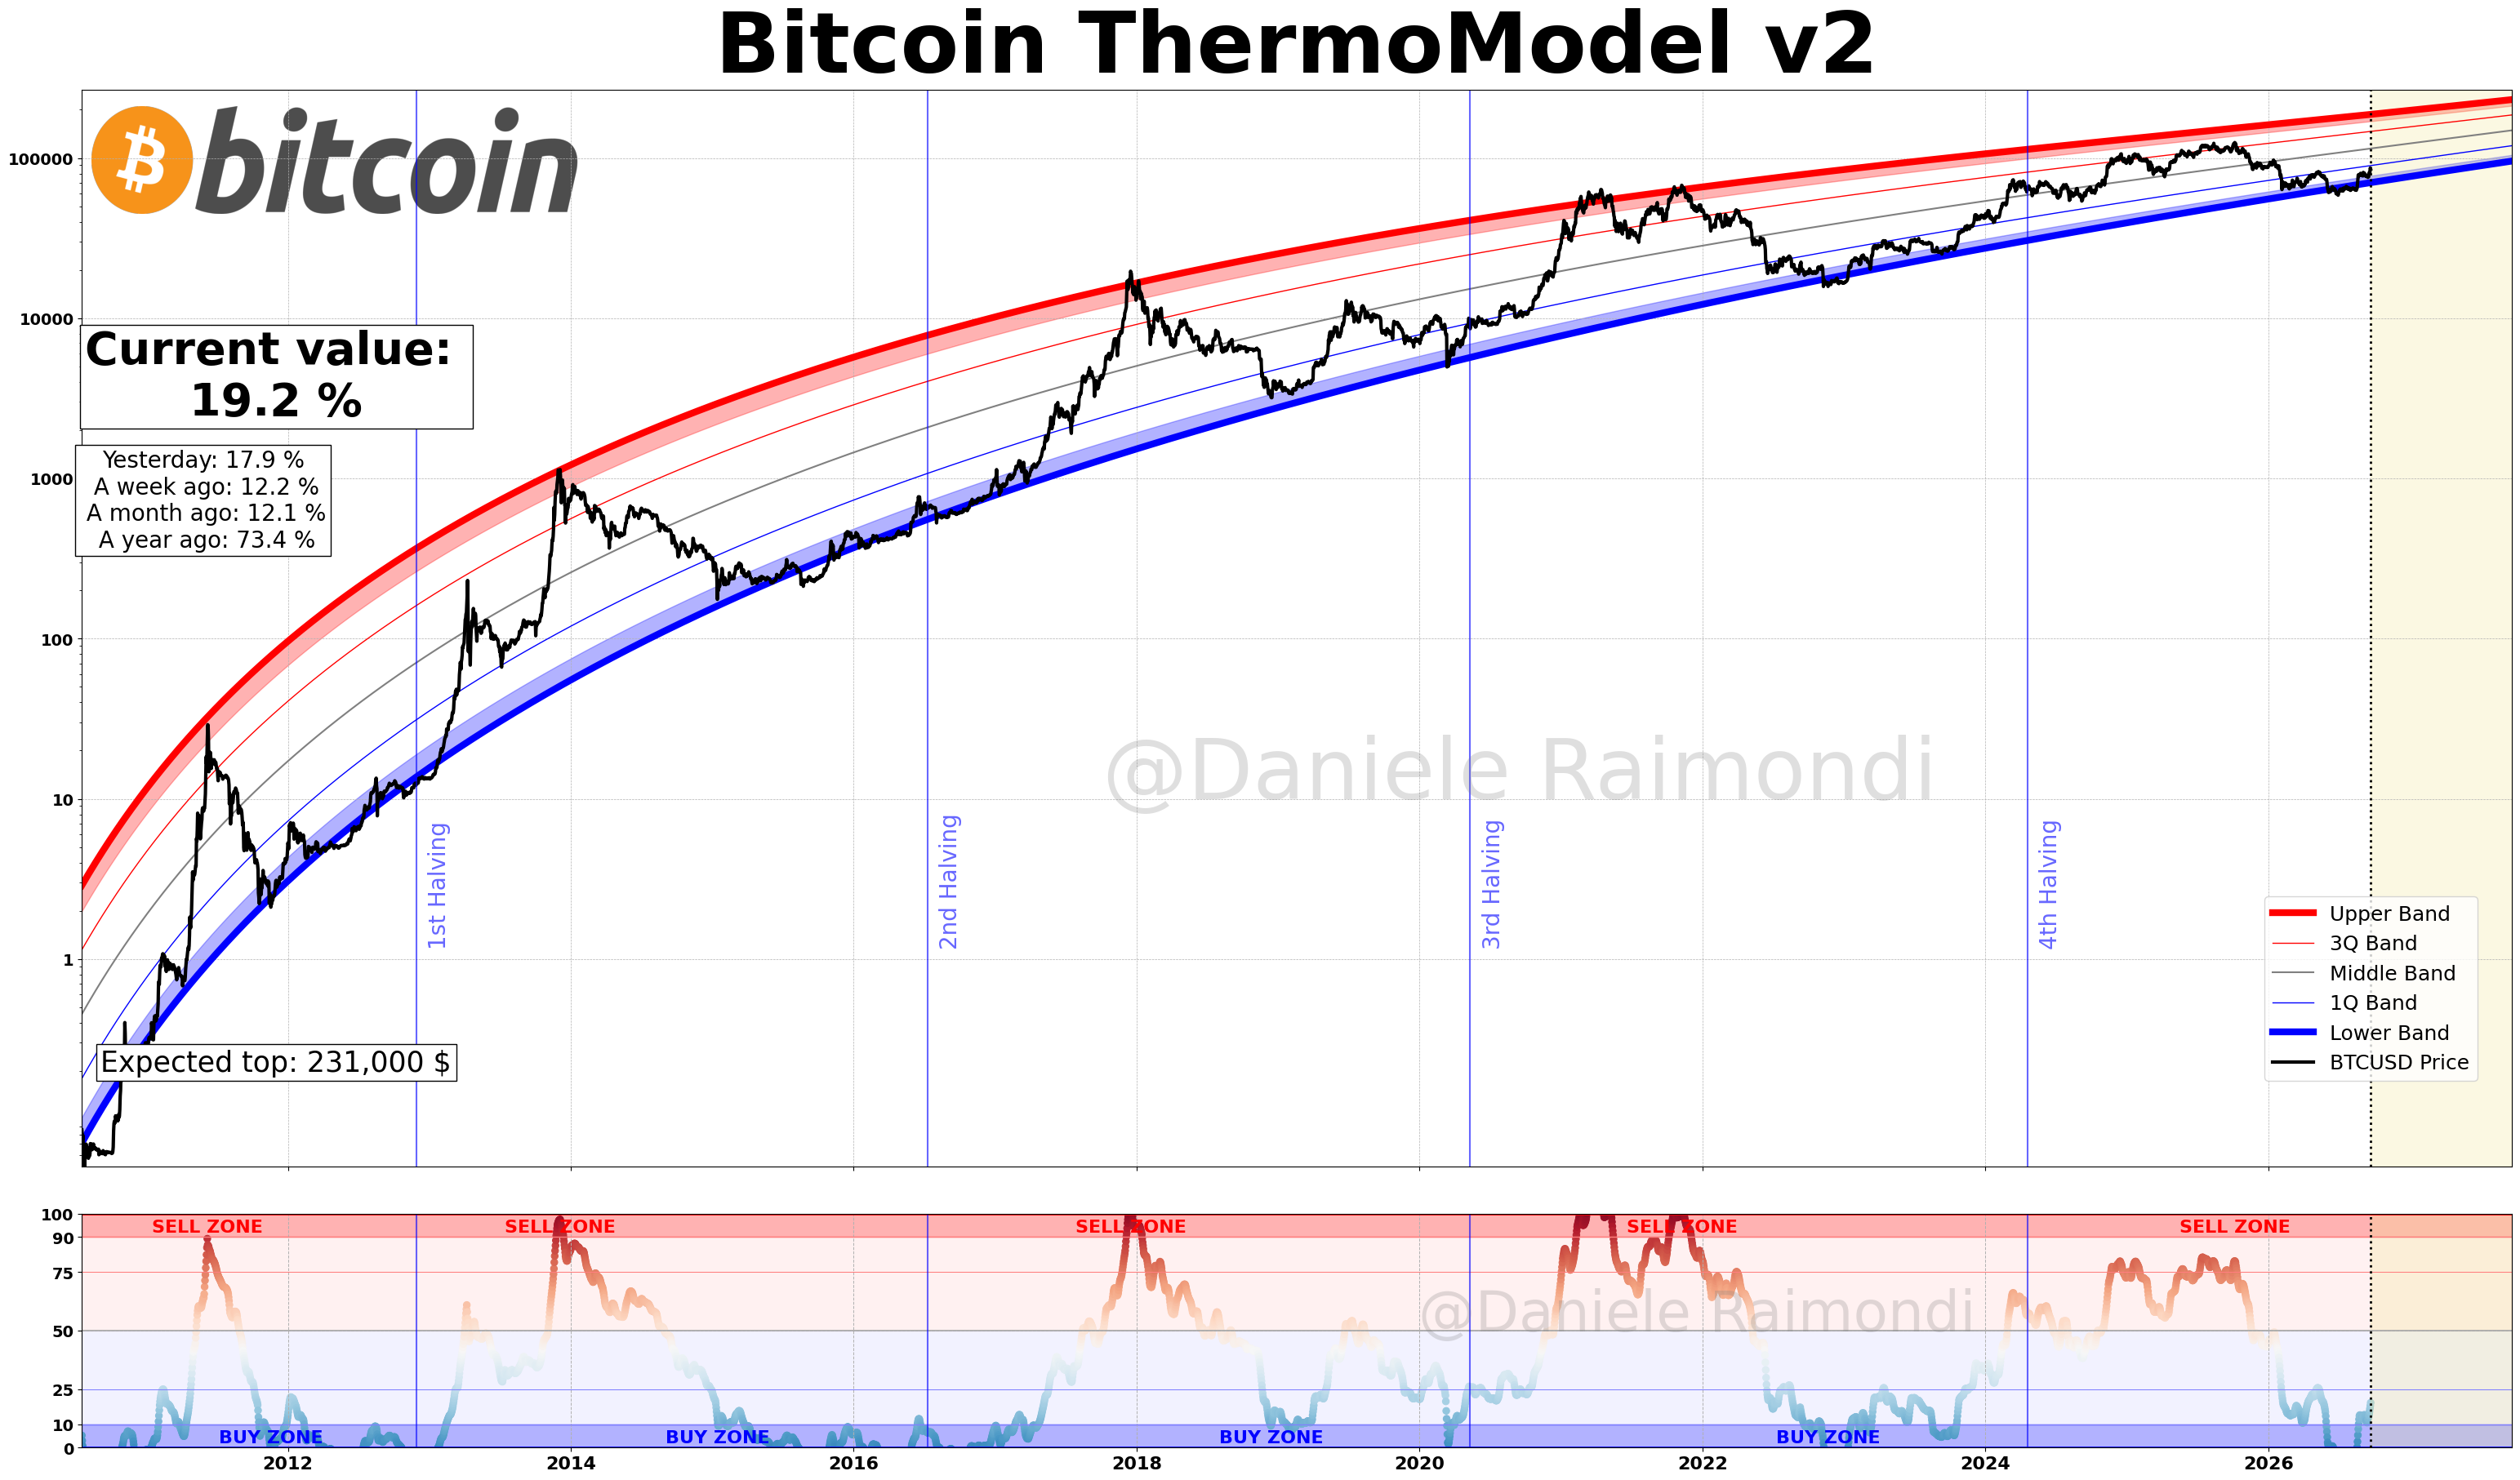

Trend: log10(price) = -16.361 + 5.644 * log10(days)   R2 = 0.962
Top multiples vs trend, cycle by cycle: [15.38, 11.15, 6.42, 2.91, 1.21] (compressing)
Bottom multiples vs trend:              [0.43, 0.55, 0.59, 0.44] (flat)

Today (2026-09-22): price $85,153  band $70,177 - $187,057
Position in band: 19.2% smoothed (19.7% raw) - the chart's readout box and the oscillator panel both show the smoothed value, as the original does.
In one year (2027-09-22): band $95,654 - $231,422   corridor midpoint $148,783


In [2]:
plot_thermomodel(df, params)

## Validation: out-of-sample top prediction, v2 vs the original

✅ BTC data fetched from CoinMetrics: 6351 rows (last: 2026-05-24)


🔄 BTC PriceUSD topped up with Yahoo Finance through 2026-09-22 (122 extra day(s)); other on-chain fields carried forward from 2026-05-23
Leave-future-out cycle top prediction

 cycle top  actual  v2 predicted  v2 error %  v1 predicted  v1 error %
2017-12-17  19,250        20,687           8        11,726         -39
2021-11-09  67,096        81,975          22       122,557          83
2025-10-06 124,824       179,498          44       494,811         296

Median |error|:  v2 (decaying band) 22.2%   vs   v1 (fixed offset) 82.7%


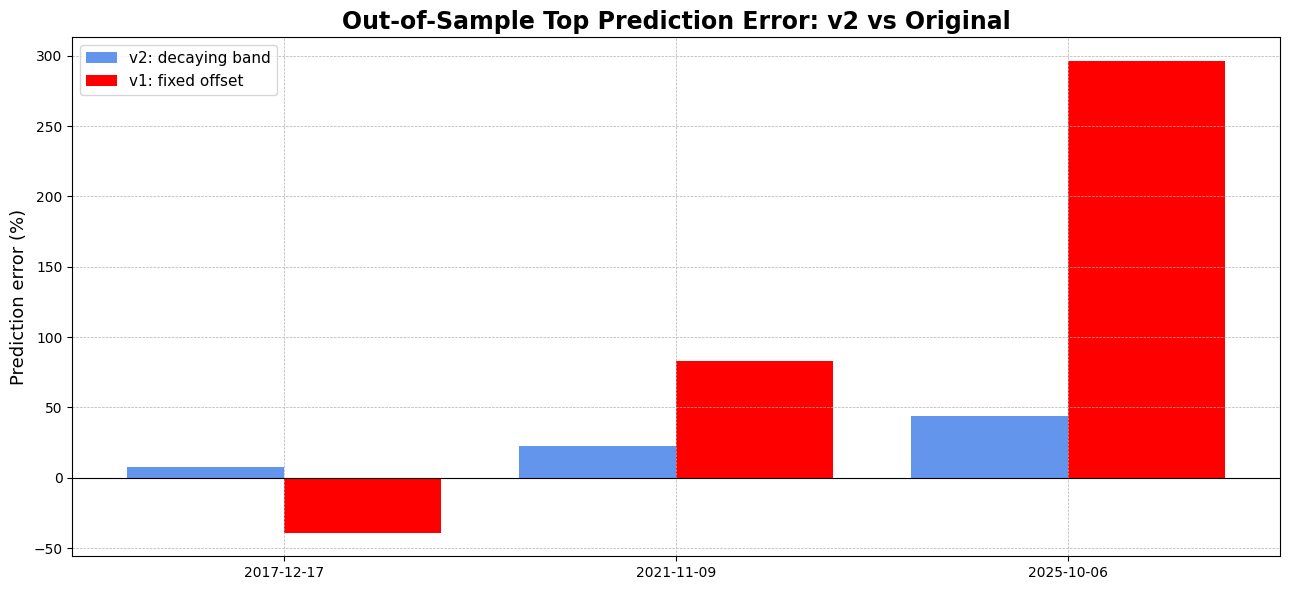

In [3]:
validation = validate_top_prediction(df)

## Where does this put the next cycle top?

In [4]:
project_next_top(df, params)

Decay of the top multiple: offset = 1.422 -0.306 * cycle_position  (floored at 0.00)

Implied cycle top if it lands on:
  Oct 2028:  trend $   260,184   upper band $    291,135   (offset +0.049 = 1.12x trend) (near the asymptote)
  Oct 2029:  trend $   343,812   upper band $    367,354   (offset +0.029 = 1.07x trend) (near the asymptote)
  Oct 2030:  trend $   448,398   upper band $    465,648   (offset +0.016 = 1.04x trend) (near the asymptote)

Read this with care. By the next cycle the linear decay has run below its asymptote,
so the band is settling onto `upper_floor` rather than still tracking the decay -
these figures are driven mostly by the trend extrapolation, and the decay itself
rests on five observations. Raise `upper_floor` in load_dataframe() for a less
aggressive assumption about how far tops keep compressing.


## A less aggressive assumption

The same model with a positive asymptote on the upper band, so that future tops are not assumed to converge all the way onto the trend line. Historical bands are identical; only the extrapolation moves.

In [5]:
df_soft, params_soft = load_dataframe(upper_floor=0.15)
project_next_top(df_soft, params_soft)

✅ BTC data fetched from CoinMetrics: 6351 rows (last: 2026-05-24)


🔄 BTC PriceUSD topped up with Yahoo Finance through 2026-09-22 (122 extra day(s)); other on-chain fields carried forward from 2026-05-23
Decay of the top multiple: offset = 1.422 -0.306 * cycle_position  (floored at 0.15)

Implied cycle top if it lands on:
  Oct 2028:  trend $   260,184   upper band $    382,019   (offset +0.167 = 1.47x trend) (near the asymptote)
  Oct 2029:  trend $   343,812   upper band $    496,251   (offset +0.159 = 1.44x trend) (near the asymptote)
  Oct 2030:  trend $   448,399   upper band $    640,961   (offset +0.155 = 1.43x trend) (near the asymptote)

Read this with care. By the next cycle the linear decay has run below its asymptote,
so the band is settling onto `upper_floor` rather than still tracking the decay -
these figures are driven mostly by the trend extrapolation, and the decay itself
rests on five observations. Raise `upper_floor` in load_dataframe() for a less
aggressive assumption about how far tops keep compressing.


# **ThermoClock: adding timing to the bands**

The bands answer *how high and how low*. They say nothing about *when*. The cycle work in `2a.Cycles` answers the opposite question and says nothing about price. Put together they produce something neither gives alone: a **dated price path**.

## The construction

1. **The clock.** Median top-to-top interval across the observed cycle tops - medians, not means, since the first cycle ran 910 days and would drag an average badly. Every date gets a phase: 0 at a cycle top, 1 at the next. Bottoms land at phase **0.26**, not 0.5: the cycle is asymmetric, roughly a year down and three years back up, and the observed top-to-bottom gaps (406, 363, 377 days) agree closely.

2. **The link.** For each slice of the cycle, where in the ThermoModel corridor did price actually sit? Measured per cycle rather than pooled, so disagreement between cycles stays visible instead of being averaged away.

3. **The projection.** The corridor at a future date (the bands are pure functions of time, so they extend exactly) combined with the historical position at that phase gives an expected price; the spread across cycles gives an envelope.

## Does it hold up?

The profile chart is the test. Every cycle starts high after a top, bottoms out near phase 0.26, and climbs back - the shape genuinely repeats, and the per-cycle curves correlate between 0.53 and 0.98.

**Where it is tight and where it is not.** Near the extremes the cycles agree closely: an interquartile spread of 11-15 percentage points at the top and at the bottom. Through the middle of the ascent they do not - the spread widens past 80 points, because how fast price climbs out of a bear market has varied enormously. Read the dated *extremes* with some confidence and the *path between them* with very little.

One further caveat on the price envelope: it reflects only uncertainty about position within the corridor. It assumes the corridor itself and the timing are both right. Each carries its own error, and neither is inside that shaded band.


✅ BTC data fetched from CoinMetrics: 6351 rows (last: 2026-05-24)


🔄 BTC PriceUSD topped up with Yahoo Finance through 2026-09-22 (122 extra day(s)); other on-chain fields carried forward from 2026-05-23


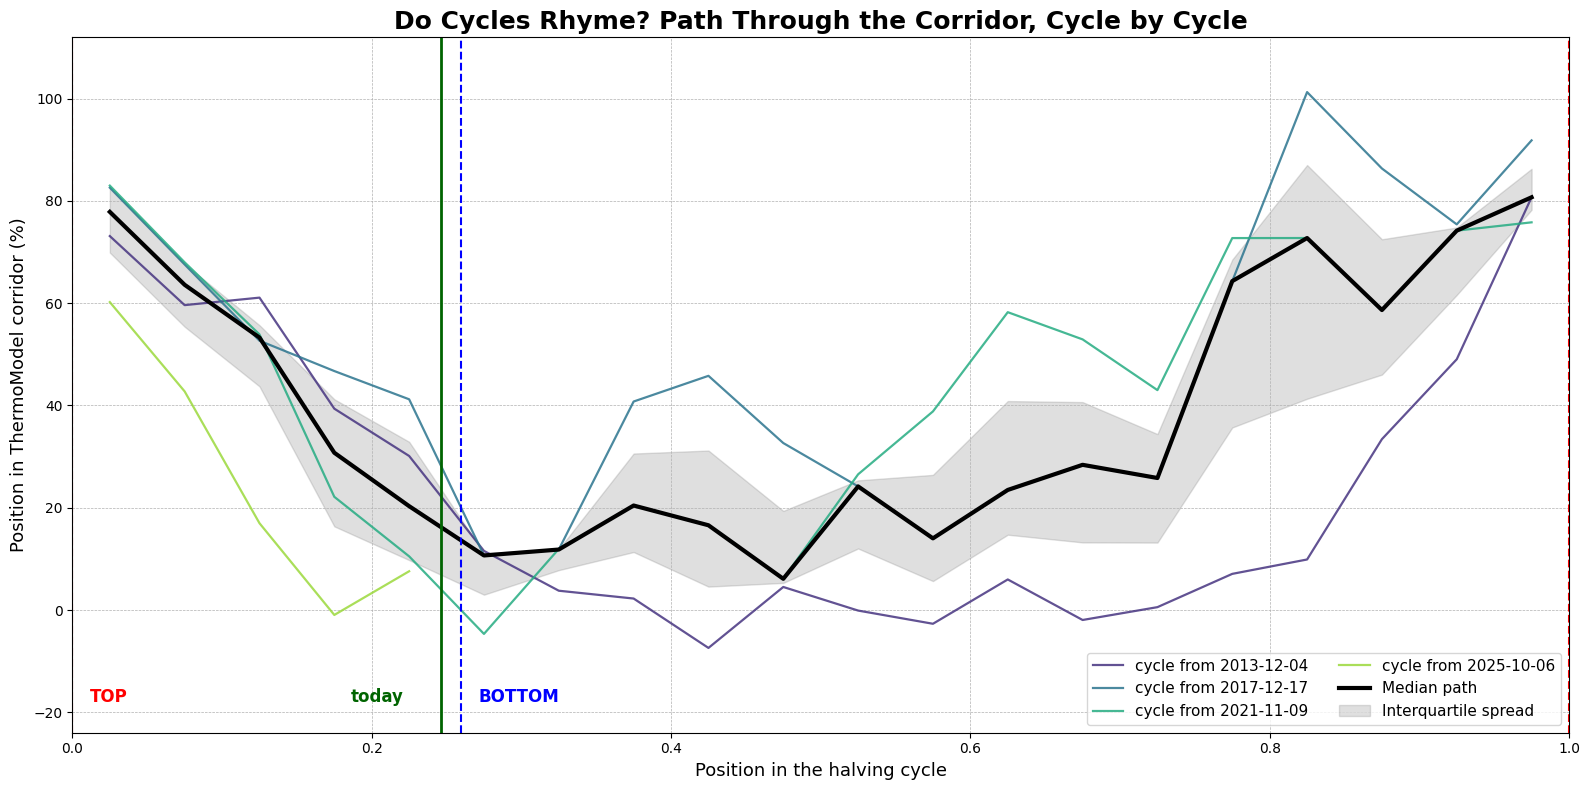

In [6]:
df_cycle, params_cycle = load_dataframe(extend_days=1250)
df_cycle = add_cycle_phase(df_cycle)
profile = fit_phase_profile(df_cycle)
df_cycle = project_cycle_path(df_cycle, profile)

plot_phase_profile(df_cycle, profile)

## The combined forecast

The chart below adds one new object to the corridor: the **orange line**, a cycle-implied price path. It is not a regression on price. It is a lookup: *at this point of the cycle, where in the corridor has price usually sat?* - converted into dollars using the corridor of that date. Four steps, stated exactly.

### 1. Position in the corridor

With $P(t)$ the price and $L(t)$, $U(t)$ the lower and upper bands, the position of price inside the corridor is

$$o(t) = \frac{\log_{10} P(t) - \log_{10} L(t)}{\log_{10} U(t) - \log_{10} L(t)}$$

so $o = 0$ sits on the lower band and $o = 1$ on the upper band. The bands are built on the log trend $\ell(t) = a + b\,\log_{10} t$ ($t$ = days since genesis) and the cycle position $c(t) = t/1458$:

$$\log_{10} L(t) = \ell(t) + \bar r_{\text{bottom}}, \qquad \log_{10} U(t) = \ell(t) + \delta_U(t), \qquad \delta_U(t) \approx \max\big(\alpha + \beta\,c(t),\ f\big)$$

where $\bar r_{\text{bottom}}$ is the mean bottom residual, $\alpha + \beta\,c$ the linear decay fitted on the five tops, and $f$ the `upper_floor` (the max is smoothed with a softplus).

### 2. The ThermoClock

With $T$ the median top-to-top interval (1425 days) and $t_0$ the last observed top (2025-10-06), every date gets a phase

$$\varphi(t) = \frac{(t - t_0) \bmod T}{T} \in [0, 1)$$

where $\varphi = 0$ is a top and $\varphi \to 1$ the next one. The modulo runs backwards over history exactly as it runs forwards into the projection.

### 3. The phase profile

Cut the phase into $K = 20$ bins $B_j$. For each cycle $k$ (the 2011 cycle is excluded), take the median position in each bin, then the median *across* cycles:

$$o_{k,j} = \operatorname*{median}\big\{\, o(t) \;:\; t \in \text{cycle } k,\ \varphi(t) \in B_j \,\big\}, \qquad \tilde o_j = \operatorname*{median}_{k}\; o_{k,j}$$

The 25th and 75th percentiles across $k$ give $\tilde o^{25}_j$ and $\tilde o^{75}_j$. These are the black line and the grey band of the profile chart above. Write $\tilde o(\varphi)$ for the linear interpolation between bin centres, wrapping around so that phase 0.99 continues smoothly into 0.01.

### 4. From position back to dollars

$$\hat P(t) = 10^{\,\log_{10} L(t) \;+\; \hat o(t)\,\left[\log_{10} U(t) - \log_{10} L(t)\right]} = L(t)^{\,1-\hat o(t)}\; U(t)^{\,\hat o(t)}, \qquad \hat o(t) = \operatorname{clip}\!\big(\tilde o(\varphi(t)),\, -0.2,\, 1.2\big)$$

That is a geometric interpolation between the two bands, which is the natural one on a log price axis. The orange shaded area is the same formula with $\tilde o^{25}$ and $\tilde o^{75}$ in place of $\tilde o$.

Nothing new is estimated for the future: the bands are functions of time and the phase is a clock, so both extend to any date. The **solid** orange line is $\hat P(t)$ on dates that already happened; the **dashed** line is the same formula from the last price onward. The two dots are $\hat P$ at $t_0 + 0.26\,T$ (next bottom) and $t_0 + T$ (next top), labelled to the month only. The bottom panel draws the asymmetric cycle wave on the same clock, so the timing driving the path is visible. The box in that panel is the clock itself: $\varphi$ evaluated today, i.e. the fraction of the top-to-top cycle already elapsed since the last top (not the height of the wave).

### How to read it

- **The solid line is not a backtest.** The profile is built from the same cycles it is then compared against, so the fit to price is in-sample by construction. The current cycle even contributes to the bins it has already covered. The out-of-sample test is the top-prediction validation above.
- **Thin evidence ahead.** For phases the current cycle has not reached yet, each bin's median rests on three cycles - in effect, the middle one.
- **The corridor shapes the path.** The dashed line inherits the compression of the upper band: as $\delta_U$ shrinks towards its floor, the same position in the corridor is worth a smaller multiple of the trend.
- **The clock is a metronome.** It lands within weeks of the last three tops (see `cycle_calls` below), and that timing error, like the corridor error, is not inside the orange band.


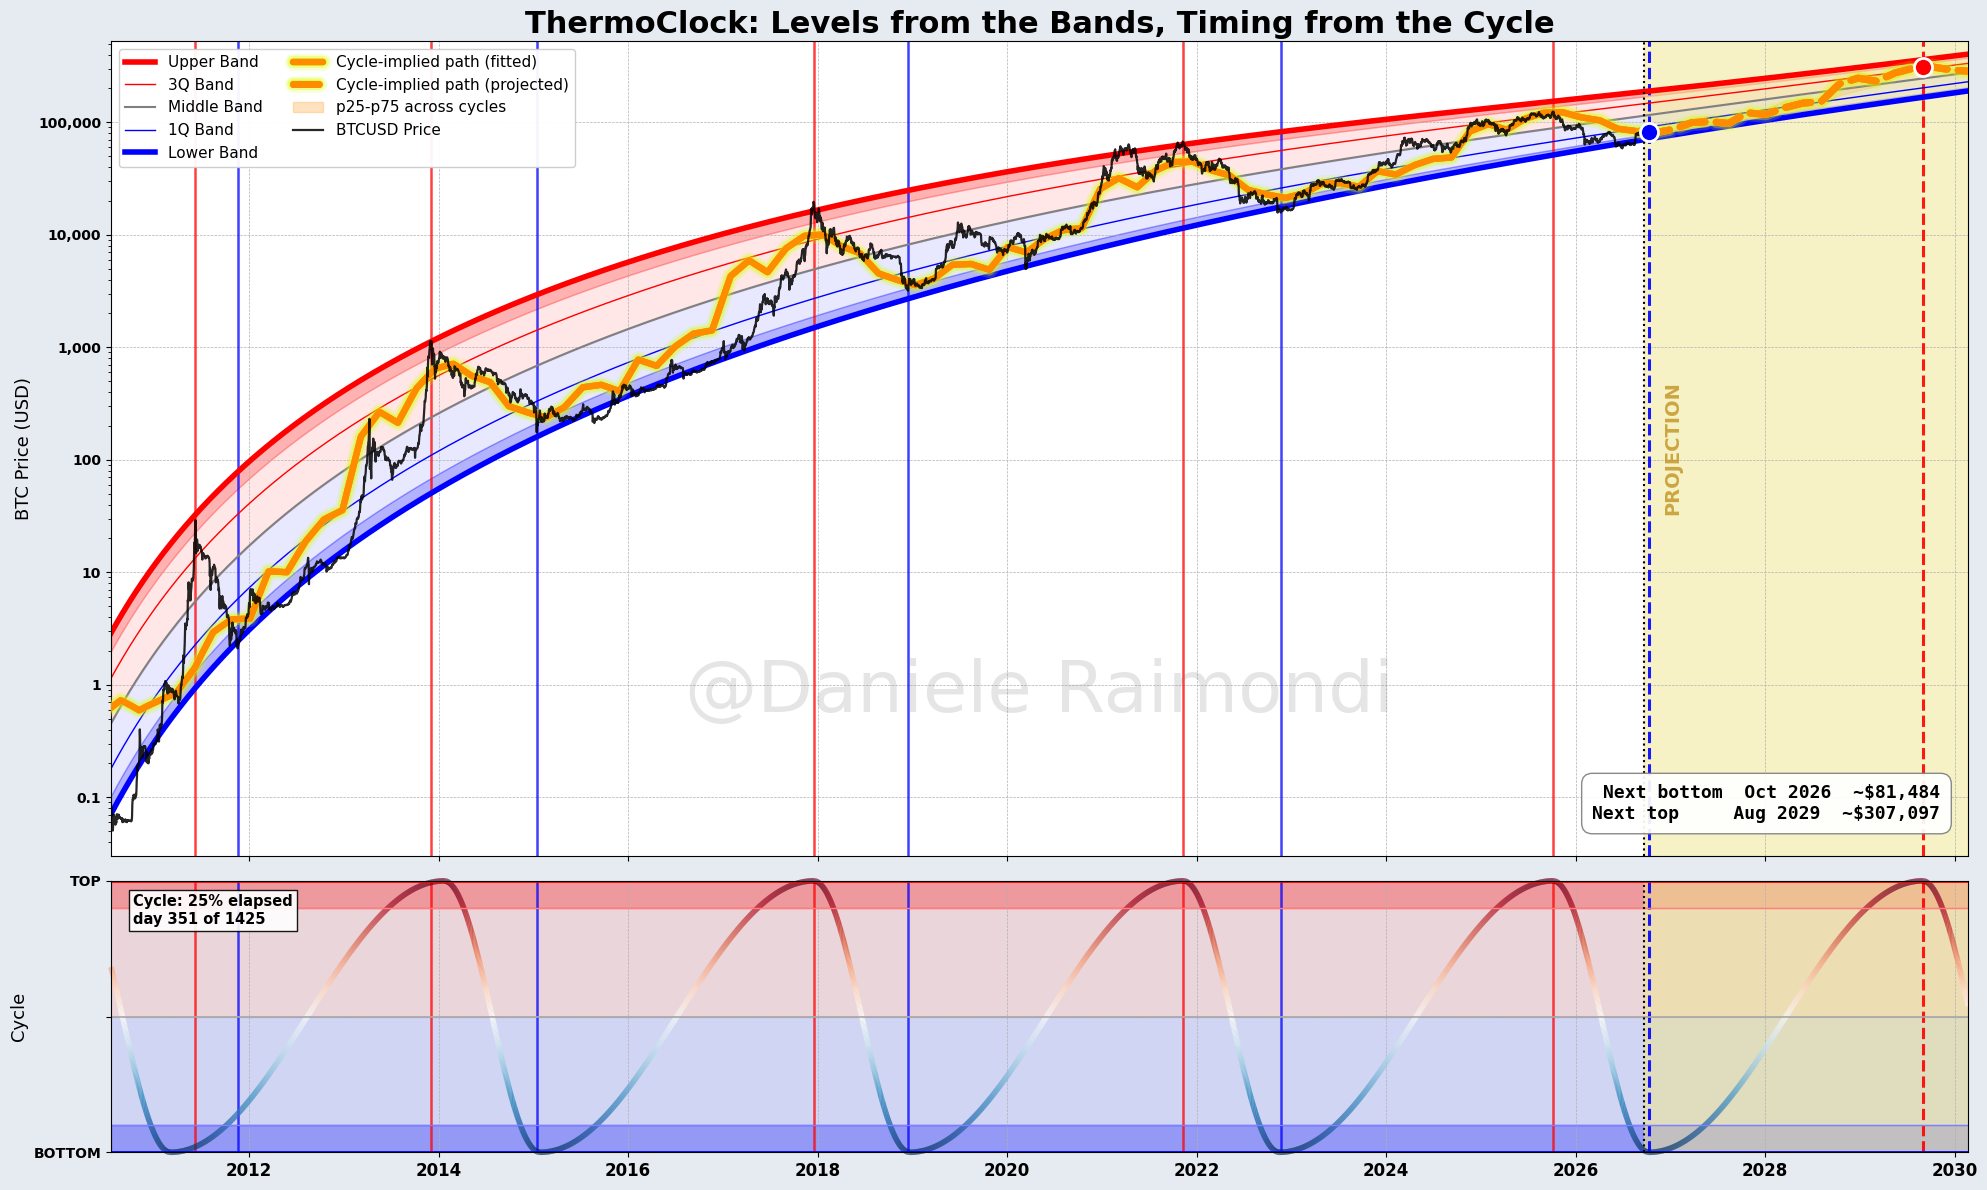

In [7]:
plot_cycle_forecast(df_cycle)

In [8]:
cycle_calls(df_cycle)

ThermoClock: period 1425 days (median top-to-top), bottom at phase 0.260
Anchored on the last top, 2025-10-06.

Today (2026-09-22) sits at phase 0.246 - 25% through the cycle.

How close the clock lands on the tops it can be checked against
(stepping back from the anchor by whole periods):
   actual Nov 2021  ->  clock says Nov 2021   off by   2 days
   actual Dec 2017  ->  clock says Dec 2017   off by   0 days
   actual Dec 2013  ->  clock says Jan 2014   off by  49 days
   actual Jun 2011  ->  clock says Feb 2010   off by 466 days
   (the oldest is the 2011 top, whose cycle ran 910 days and is the outlier
    the median period deliberately ignores)

Next cycle BOTTOM: October 2026
   corridor then:     $71,348 - $189,099
   expected price:    $81,484   (p25-p75 $74,966 - $84,866)
Next cycle TOP: August 2029
   corridor then:     $166,956 - $360,081
   expected price:    $307,097   (p25-p75 $295,052 - $319,619)

The corridor is the reliable half of this. The timing rests on four top-t